Here is the second part of the manual pipeline, we assume every tests of the alpha notebook passed successfuly 

In [ ]:
from pathlib import Path
import sys
import io
from contextlib import contextmanager, redirect_stdout, redirect_stderr
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from importlib import reload

@contextmanager
def suppress_output():
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield

# Auto-configure paths from centralized config
from benchmark_config import (
    PROJECT_ROOT, SRC_ROOT, ADBENCH_ROOT, ADBENCH_DATASETS,
    DATASET_CONFIG, TEST_SCENARIOS, EVAL_DATASETS,
    get_scenario, get_model_config
)

# Ensure paths are in sys.path
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if str(ADBENCH_ROOT) not in sys.path:
    sys.path.append(str(ADBENCH_ROOT))

from utils import create_models

import base
base = reload(base)
from base import Model, Data, CoLearning
from colearner import SimpleCoLearner, SingleModel, CoLearnerVal
from strategy import SimpleStrategy, PlateauStrategy, AdaptivePlateauStrategy
import baselines.adbench.ModelWrapperADBench as mw
mw = reload(mw)
from baselines.adbench.ModelWrapperADBench import PYOD_AVAILABLE
from baselines.adbench.data_loader import load_data

print(f"Project root: {PROJECT_ROOT}")
print(f"Datasets dir: {ADBENCH_DATASETS}")

2026-02-09 09:24:06.805022: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 09:24:06.831469: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-09 09:24:06.831508: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-09 09:24:06.831524: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-09 09:24:06.836326: I tensorflow/core/platform/cpu_feature_g

Project root: /home/peppino58/CoBench
Datasets dir: /home/peppino58/CoBench/SubModules/ADBench/adbench/datasets/Classical


In [3]:
# Data loading configuration
TRAIN_SPLIT = 0.60
VAL_TEST_SPLIT = 0.50
SEMI_LABEL_RATIO = 0.10
SEMI_STRATIFIED = True
PRESERVE_LABELED = True

from baselines.adbench.data_loader import ClassicalADBenchData

In [ ]:
print("EVAL 1: Solo Baseline Performance Across Datasets")

if 'registry' not in locals():
    registry = mw.get_model_detector_dict()

# Use centralized EVAL_DATASETS from benchmark_config
eval_solo_results, eval1_rows, model_names_map = {}, [], {}

for dataset_name, dataset_path in EVAL_DATASETS.items():
    try:
        data_eval = ClassicalADBenchData(
            dataset_path,
            train_test_split_ratio=TRAIN_SPLIT,
            val_test_split_ratio=VAL_TEST_SPLIT,
            preserve_labeled=PRESERVE_LABELED
        )
        data_eval.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)
        
        with suppress_output():
            models_eval = create_models(registry, ["prenet", "deepsad"], data_eval)
        dataset_results, auc_list = {}, []
        for i, model in enumerate(models_eval):
            with suppress_output():
                model.fit()
            auc = roc_auc_score(data_eval.y_test, model.predict_scores())
            key = f"model_{i}"
            dataset_results[key] = auc
            model_names_map[key] = model.__class__.__name__
            auc_list.append(auc)
            eval1_rows.append({"Dataset": dataset_name, "Model": model.__class__.__name__, "Solo AUC": auc})
        ensemble_auc = float(np.mean(auc_list)) if auc_list else 0.0
        dataset_results["ensemble"] = ensemble_auc
        eval1_rows.append({"Dataset": dataset_name, "Model": "Ensemble", "Solo AUC": ensemble_auc})
        eval_solo_results[dataset_name] = dataset_results
    except Exception as e:
        print(f"Failed: {dataset_name} - {str(e)[:80]}")
        eval_solo_results[dataset_name] = None

print("EVAL 1: Solo Baseline Table (AUC)")
if eval1_rows:
    df_eval1 = pd.DataFrame(eval1_rows)
    table = df_eval1.pivot(index="Dataset", columns="Model", values="Solo AUC")

    print(table.to_string(float_format=lambda x: f"{x:.4f}"))
    successful = sum(1 for v in eval_solo_results.values() if v is not None)
    print(f"  Successfully tested: {successful} / {len(EVAL_DATASETS)} datasets")


EVAL 1: Solo Baseline Performance Across Datasets
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
EVAL 1: Solo Baseline Table (AUC)
Model       DeepSADWrapper  Ensemble  PReNetWrapper
Dataset                                            
Ionosphere          0.8356    0.8209         0.8062
annthyroid          0.9033    0.8242         0.7451
cardio              0.9525    0.9518         0.9511
letter              0.8172    0.710

In [ ]:
print("EVAL 2: Collaborative Learning vs Solo Baseline")

if 'registry' not in locals():
    registry = mw.get_model_detector_dict()

eval_collab_results = {}
eval2_data = []
model_names_map = model_names_map if 'model_names_map' in locals() else {}

for dataset_name, dataset_path in EVAL_DATASETS.items():
    try:
        solo_aucs = eval_solo_results[dataset_name]
        
        data_eval_collab = ClassicalADBenchData(
            dataset_path,
            train_test_split_ratio=TRAIN_SPLIT,
            val_test_split_ratio=VAL_TEST_SPLIT,
            preserve_labeled=PRESERVE_LABELED
        )
        data_eval_collab.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)
        
        with suppress_output():
            models_collab = create_models(registry, ["prenet", "deepsad"], data_eval_collab)
        if not model_names_map:
            for idx, model in enumerate(models_collab):
                model_names_map[f"model_{idx}"] = model.__class__.__name__
        
        strategy = PlateauStrategy(metric_key="ensemble", mode="max", patience=5, min_delta=0.001)
        colearner_eval = CoLearnerVal(
            models=models_collab,
            data=data_eval_collab,
            strategy=strategy,
            warmup_epochs=10,
            max_chapters=10,
            anomaly_threshold=0.5,
            confidence_threshold_low=0.05,
            confidence_threshold_high=0.95,
        )
        with suppress_output():
            history_eval = colearner_eval.cotrain(eval_interval=1)

        collab_metrics_eval = {}
        test_scores_list = []
        for i, model in enumerate(models_collab):
            model_test_scores = model.predict_scores()
            test_scores_list.append(model_test_scores)
            try:
                model_auc = roc_auc_score(data_eval_collab.y_test, model_test_scores)
            except Exception:
                model_auc = 0.5
            collab_metrics_eval[f"model_{i}"] = model_auc

        try:
            ensemble_scores = np.mean(np.array(test_scores_list), axis=0)
            ensemble_auc = roc_auc_score(data_eval_collab.y_test, ensemble_scores)
        except Exception:
            ensemble_auc = 0.5
        collab_metrics_eval["ensemble"] = ensemble_auc
        
        for key, solo_val in solo_aucs.items():
            if key != "ensemble":
                model_name = model_names_map.get(key, key)
                collab_val = collab_metrics_eval.get(key, 0.0)
                delta = collab_val - solo_val
                delta_pct = (delta / solo_val * 100) if solo_val > 0 else 0
                eval2_data.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Solo Model": solo_val,
                    "Collab Model": collab_val,
                    "Model Δ": delta,
                    "Model Δ%": delta_pct
                })
        
        solo_ensemble = solo_aucs.get("ensemble", 0.0)
        collab_ensemble = collab_metrics_eval.get("ensemble", 0.0)
        ens_delta = collab_ensemble - solo_ensemble
        ens_delta_pct = (ens_delta / solo_ensemble * 100) if solo_ensemble > 0 else 0
        eval2_data.append({
            "Dataset": dataset_name,
            "Model": "Ensemble",
            "Solo Model": solo_ensemble,
            "Collab Model": collab_ensemble,
            "Model Δ": ens_delta,
            "Model Δ%": ens_delta_pct
        })
        
        eval_collab_results[dataset_name] = {
            "solo": solo_aucs,
            "collaborative": collab_metrics_eval,
            "model_names": model_names_map,
            "history_val": history_eval
        }
    except Exception as e:
        print(f"Failed: {dataset_name} - {str(e)[:80]}")
        eval_collab_results[dataset_name] = None

print("\n" + "="*70)
print("EVAL 2: Detailed Results (Test AUC)")
print("="*70)
if eval2_data:
    df_eval2 = pd.DataFrame(eval2_data)
    successful = sum(1 for v in eval_collab_results.values() if v is not None)
    print(df_eval2.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"  Successfully tested: {successful} / {len(EVAL_DATASETS)} datasets")


EVAL 2: Collaborative Learning vs Solo Baseline
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
Failed: letter - 'a' cannot be empty unless no samples are taken
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
Failed: satellite - 'a' cannot be empty unless no samples are taken

EVAL 2: Detailed Results (Test AUC)
   Dataset          Model  Solo Model  Collab Model  Model Δ  Model Δ%
annthyroid  PReNetWrapper      0.7451        0.8506   0.1056   14.1688
annthyroid DeepSADW

## Validation Loss Proxy Explained

In anomaly detection, we don't have a direct "validation loss" like in supervised classification. Instead, we use **Validation Loss Proxy = 1 - AUC**.

### Why?
| Metric | Range | Interpretation |
|--------|-------|----------------|
| **AUC** | [0.5, 1.0] | Higher = better (1.0 = perfect) |
| **Loss Proxy** | [0.0, 0.5] | Lower = better (0.0 = perfect) |

### Visualization
- **Left plot**: Actual training loss from model internals
- **Right plot**: Validation performance (1 - AUC) per chapter
- **Red markers**: Points where pseudo-label exchange occurred

### Exchange Impact
After each exchange, models receive pseudo-labels from peers. If effective:
- Loss should decrease (better fitting)
- AUC should increase (better discrimination)
- The exchange markers let us see if there's a "jump" in performance post-exchange

EVAL 2b: Training + Validation Loss with Exchange Markers + Precision

Training on annthyroid...
  Labeled samples: 432
  Unlabeled samples: 3888
  Validation samples: 1440 (X_val shape: (1440, 6))
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
number of gpu: 1
cuda name: NVIDIA GeForce RTX 2050
GPU is on
    [Strategy] Stop triggered (count=1), patience: 5 → 4
  PReNetWrapper: 85 training loss values recorded
  DeepSADWrapper: 85 training loss values recorded
  PReNetWrapper: 85 validation loss values recorded
  DeepSADWrapper: 85 validation loss values recorded

Exchange Statistics (on unlabeled samples only):
   Chapter 1: Anomaly 192/1024 (18.75%), Normal 6368/6752 (94.31%)
   Chapter 2: Anomaly 58/60 (96.67%), Normal 7198/7716 (93.29%)
   Chapter 3: Anomaly 57/59 (96.61%), Normal 7198/7717 (93.27%)
   Chapter 4: Anomaly 58/59 (98.31%), Normal 7199/7717 (93.29%)
   Chapter 5: Anomaly 54/56 (96.43%), Normal 7198/7720 (93.24%)
   Chapter 6: Anomaly 56/60 (93.33%), Norm

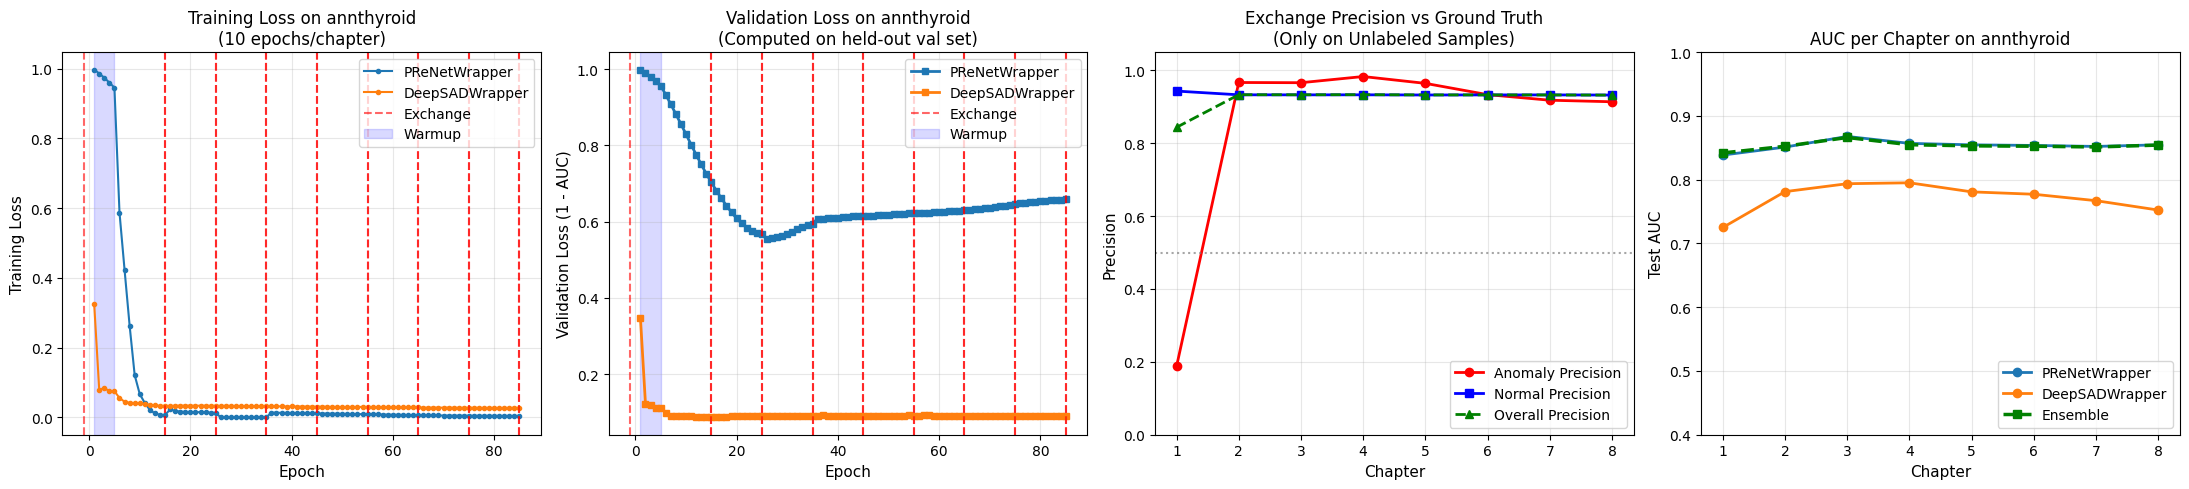


Configuration:
   Warmup: 5 epochs | Chapters: 8 | Epochs/Chapter: 10
   Total training epochs: 85
Validation loss computed on 1440 held-out samples at each epoch
   Strategy: AdaptivePlateauStrategy (patience: 5 → 4)

 Pseudo-labels exchanged ONLY on unlabeled samples (3888 samples)
   Stop triggers: 1


In [ ]:
print("EVAL 2b: Training + Validation Loss with Exchange Markers + Precision")

%matplotlib inline 
import matplotlib.pyplot as plt

dataset_name = "annthyroid"
dataset_path = EVAL_DATASETS[dataset_name]

print(f"\nTraining on {dataset_name}...")

data_loss = ClassicalADBenchData(
    dataset_path,
    train_test_split_ratio=TRAIN_SPLIT,
    val_test_split_ratio=VAL_TEST_SPLIT,
    preserve_labeled=PRESERVE_LABELED
)
data_loss.generate_semisupervised_split(labeled_ratio=SEMI_LABEL_RATIO, stratified=SEMI_STRATIFIED)

print(f"  Labeled samples: {len(data_loss.labeled_indexes)}")
print(f"  Unlabeled samples: {len(data_loss.unlabeled_indexes)}")
print(f"  Validation samples: {data_loss.n_val} (X_val shape: {data_loss.X_val.shape if data_loss.X_val is not None else 'None'})")

models_loss = create_models(registry, ["prenet", "deepsad"], data_loss)

# CONFIG
WARMUP_EPOCHS = 5
MAX_CHAPTERS = 15
EPOCHS_PER_CHAPTER = 10 

# Use AdaptivePlateauStrategy
strategy_loss = AdaptivePlateauStrategy(
    metric_key="ensemble", 
    mode="max", 
    patience=5,
    min_delta=0.001,
    decay_rate=1,
    min_patience=1
)

colearner_loss = CoLearnerVal(
    models=models_loss,
    data=data_loss,
    strategy=strategy_loss,
    warmup_epochs=WARMUP_EPOCHS,
    max_chapters=MAX_CHAPTERS,
    epochs_per_chapter=EPOCHS_PER_CHAPTER,
    anomaly_threshold=0.5,
    confidence_threshold_low=0.2,
    confidence_threshold_high=0.6,
)

history_loss = colearner_loss.cotrain(eval_interval=1)


fig, axes = plt.subplots(1, 4, figsize=(22, 5))
# train loss
model_names_map = {f'model_{i}': m.__class__.__name__ for i, m in enumerate(models_loss)}
for i, model in enumerate(models_loss):
    model_name = model.__class__.__name__
    if hasattr(model, '_train_loss_history') and model._train_loss_history:
        losses = model._train_loss_history
        epochs = range(1, len(losses) + 1)
        axes[0].plot(epochs, losses, label=model_name, marker='o', markersize=3)
        print(f"  {model_name}: {len(losses)} training loss values recorded")
        
        # highlight exchange epochs
        n_chapters = len(history_loss.get("chapters", []))
        exchange_epochs = [WARMUP_EPOCHS + (c * EPOCHS_PER_CHAPTER) for c in range(1, n_chapters + 1)]
        for ex_ep in exchange_epochs:
            if ex_ep <= len(losses):
                axes[0].axvline(x=ex_ep, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    else:
        print(f"  {model_name}: No training loss history available")

axes[0].axvline(x=-1, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Exchange')
axes[0].axvspan(1, WARMUP_EPOCHS, alpha=0.15, color='blue', label='Warmup')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Training Loss", fontsize=11)
axes[0].set_title(f"Training Loss on {dataset_name}\n({EPOCHS_PER_CHAPTER} epochs/chapter)", fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# validation loss 
colors_val = ['C0', 'C1', 'C2', 'C3']
has_val_loss = bool(colearner_loss.val_loss_history)

for i, model in enumerate(models_loss):
    model_name = model.__class__.__name__
    val_loss_history = colearner_loss.val_loss_history.get(i, [])
    
    if val_loss_history and any(v is not None for v in val_loss_history):
        valid_losses = [(ep, v) for ep, v in enumerate(val_loss_history, 1) if v is not None]
        if valid_losses:
            epochs, losses = zip(*valid_losses)
            axes[1].plot(epochs, losses, label=f"{model_name}", 
                         marker='s', markersize=4, color=colors_val[i], linewidth=2)
            print(f"  {model_name}: {len(valid_losses)} validation loss values recorded")
            
            # Mark exchange points
            n_chapters = len(history_loss.get("chapters", []))
            exchange_epochs = [WARMUP_EPOCHS + (c * EPOCHS_PER_CHAPTER) for c in range(1, n_chapters + 1)]
            for ex_ep in exchange_epochs:
                if ex_ep <= max(epochs):
                    axes[1].axvline(x=ex_ep, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    else:
        print(f"  {model_name}: No validation loss history available")

if has_val_loss:
    axes[1].axvline(x=-1, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Exchange')
    axes[1].axvspan(1, WARMUP_EPOCHS, alpha=0.15, color='blue', label='Warmup')
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Validation Loss (model-reported)", fontsize=11)
    axes[1].set_title(f"Validation Loss on {dataset_name}\n(Computed on held-out val set)", fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No validation loss available", ha='center', va='center', 
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Validation Loss", fontsize=12)

# --- Plot 3: Exchange Precision ---
exchange_history = colearner_loss.exchange_history
if exchange_history:
    ex_chapters = range(1, len(exchange_history) + 1)
    anomaly_prec = [e.get("anomaly_precision", 0) for e in exchange_history]
    normal_prec = [e.get("normal_precision", 0) for e in exchange_history]
    overall_prec = [e.get("overall_precision", 0) for e in exchange_history]
    
    axes[2].plot(ex_chapters, anomaly_prec, label='Anomaly Precision', marker='o', color='red', linewidth=2)
    axes[2].plot(ex_chapters, normal_prec, label='Normal Precision', marker='s', color='blue', linewidth=2)
    axes[2].plot(ex_chapters, overall_prec, label='Overall Precision', marker='^', color='green', linewidth=2, linestyle='--')
    
    axes[2].set_ylim(0, 1.05)
    axes[2].set_xlabel("Chapter", fontsize=11)
    axes[2].set_ylabel("Precision", fontsize=11)
    axes[2].set_title("Exchange Precision vs Ground Truth\n(Only on Unlabeled Samples)", fontsize=12)
    axes[2].legend(loc='lower right')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Random')
    
    # Print exchange stats
    print(f"\nExchange Statistics (on unlabeled samples only):")
    for i, e in enumerate(exchange_history):
        print(f"   Chapter {i+1}: Anomaly {e['correct_anomalies']}/{e['n_anomalies']} ({e['anomaly_precision']:.2%}), "
              f"Normal {e['correct_normals']}/{e['n_normals']} ({e['normal_precision']:.2%})")
else:
    axes[2].text(0.5, 0.5, "No exchange history\n(run cotrain first)", ha='center', va='center', 
                 transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title("Exchange Precision", fontsize=12)

# --- Plot 4: AUC per Chapter ---
chapters_data = history_loss.get("chapters", [])
if chapters_data:
    chapter_nums = range(1, len(chapters_data) + 1)
    model_aucs = {i: [] for i in range(len(models_loss))}
    ensemble_aucs = []
    
    for chapter in chapters_data:
        # CoLearnerVal stores metrics directly in the chapter dict
        chapter_metrics = chapter if isinstance(chapter, dict) else {}
        for i in range(len(models_loss)):
            key = f"model_{i}"
            model_aucs[i].append(chapter_metrics.get(key, float('nan')))
        ensemble_aucs.append(chapter_metrics.get("ensemble", float('nan')))
    
    # Plot individual model AUCs
    for i, model in enumerate(models_loss):
        model_name = model.__class__.__name__
        axes[3].plot(chapter_nums, model_aucs[i], label=model_name, marker='o', linewidth=2)
    
    # Plot ensemble AUC
    axes[3].plot(chapter_nums, ensemble_aucs, label='Ensemble', marker='s', linewidth=2.5, linestyle='--', color='green')
    
    axes[3].set_xlabel("Chapter", fontsize=11)
    axes[3].set_ylabel("Validation AUC", fontsize=11)
    axes[3].set_title(f"AUC per Chapter on {dataset_name}", fontsize=12)
    axes[3].legend(loc='lower right')
    axes[3].grid(True, alpha=0.3)
    axes[3].set_ylim([0.4, 1.0])
    
    print(f"\nAUC per Chapter:")
    for i, model in enumerate(models_loss):
        model_name = model.__class__.__name__
        print(f"   {model_name}: {model_aucs[i]}")
    print(f"   Ensemble: {ensemble_aucs}")
else:
    axes[3].text(0.5, 0.5, "No chapter data\n(run cotrain first)", ha='center', va='center', 
                 transform=axes[3].transAxes, fontsize=12)
    axes[3].set_title("AUC per Chapter", fontsize=12)

plt.tight_layout()
plt.savefig("training_validation_precision_curves.png", dpi=150)
plt.show()

print("\nConfiguration:")
print(f"   Warmup: {WARMUP_EPOCHS} epochs | Chapters: {len(history_loss.get('chapters', []))} | Epochs/Chapter: {EPOCHS_PER_CHAPTER}")

print(f"   Total training epochs: {WARMUP_EPOCHS + len(history_loss.get('chapters', [])) * EPOCHS_PER_CHAPTER}")
print(f"Validation loss computed on {data_loss.n_val} held-out samples at each epoch")

print(f"   Strategy: AdaptivePlateauStrategy (patience: {strategy_loss.initial_patience} → {strategy_loss.patience})")
print(f"\n Pseudo-labels exchanged ONLY on unlabeled samples ({len(data_loss.unlabeled_indexes)} samples)")
print(f"   Stop triggers: {strategy_loss.stop_count}")